# Crime Data Analysis and Forecasting

Analysis and predictive modelling of England and Wales police-recorded crime data (2016-2025), focusing on CSP-level offence count forecasting using Random Forest and XGBoost regressors.

---
## Imports and Setup

Importing all required libraries for data processing, visualisation, and machine learning.

In [1]:
# import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
from xgboost import XGBRegressor
from google.colab import drive

---
## Data Loading

Mounting Google Drive and loading the raw crime statistics CSV files for 2016-2020 and 2020-2025.

In [2]:
# mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path_16_20 = "/content/drive/MyDrive/DataScience_Data/2016_20.csv"
path_20_25 = "/content/drive/MyDrive/DataScience_Data/2020_25.csv"

# Read both csv's as dicts
df_16_20 = pd.read_csv(path_16_20)
df_20_25 = pd.read_csv(path_20_25)

# Create a dict with all data
df_total = pd.concat([df_16_20, df_20_25])

---
## Exploratory Data Analysis

Inspecting data shape, column names, unique values, and identifying inconsistencies in categorical fields.

In [4]:
# Shape of the total dict
df_total.shape

(1904906, 9)

In [5]:
# list column names
df_total.columns

Index(['Financial Year', 'Financial Quarter', 'Police Force',
       'CSP Name merged', 'Offence Description', 'Offence Group',
       'Offence Subgroup', 'Offence Code', 'Offence Count'],
      dtype='object')

In [6]:
# preview first rows
df_total.head()

,Financial Year,Financial Quarter,Police Force,CSP Name merged,Offence Description,Offence Group,Offence Subgroup,Offence Code,Offence Count
0,2015/16,1.0,Avon and Somerset,Bath and North East Somerset,Absconding from lawful custody,Miscellaneous crimes against society against s...,Miscellaneous crimes against society,80,0.0
1,2015/16,1.0,Avon and Somerset,Bath and North East Somerset,Abuse of children through sexual exploitation,Sexual offences,Other sexual offences,71,0.0
2,2015/16,1.0,Avon and Somerset,Bath and North East Somerset,Abuse of position of trust of a sexual nature,Sexual offences,Other sexual offences,73,0.0
3,2015/16,1.0,Avon and Somerset,Bath and North East Somerset,Aggravated burglary in a building other than a...,Theft offences,Non-domestic burglary,31,0.0
4,2015/16,1.0,Avon and Somerset,Bath and North East Somerset,Aggravated burglary in a dwelling (outcome only),Theft offences,Domestic burglary,29,0.0


In [7]:
# check unique financial years
print(df_total["Financial Year"].unique())

['2015/16' '2016/17' '2017/18' '2018/19' '2019/20' nan '2020/21' '2021/22'
 '2022/23' '2023/24' '2024/25']


In [8]:
# check unique financial quarters
print(df_total["Financial Quarter"].unique())

[ 1.  2.  3.  4. nan]


In [9]:
# check unique police forces
print(df_total["Police Force"].unique())

['Avon and Somerset' 'Bedfordshire' 'Cambridgeshire' 'Cheshire'
 'Cleveland' 'Cumbria' 'Derbyshire' 'Devon and Cornwall' 'Dorset' 'Durham'
 'Dyfed-Powys' 'Essex' 'Gloucestershire' 'Greater Manchester' 'Gwent'
 'Hampshire' 'Hertfordshire' 'Humberside' 'Kent' 'Lancashire'
 'Leicestershire' 'Lincolnshire' 'London, City of' 'Merseyside'
 'Metropolitan Police' 'Norfolk' 'North Wales' 'North Yorkshire'
 'Northamptonshire' 'Northumbria' 'Nottinghamshire' 'South Wales'
 'South Yorkshire' 'Staffordshire' 'Suffolk' 'Surrey' 'Sussex'
 'Thames Valley' 'Warwickshire' 'West Mercia' 'West Midlands'
 'West Yorkshire' 'Wiltshire' nan]


In [10]:
# Get unique Police Force containing "London" with counts
london_names  = df_total[df_total['Police Force'].str.contains('London', na=False)]['Police Force'].value_counts()

print("Unique Police Force containing 'London' with counts:")
for city, count in london_names .items():
    print(f"  - {city}: {count:,} records")

print(f"\nTotal 'London' records: {london_names .sum():,}")

Unique Police Force containing 'London' with counts:
  - London, City of: 6,820 records

Total 'London' records: 6,820


In [11]:
# fix London naming and show counts
df_total['Police Force'] = df_total['Police Force'].replace('London, City of', 'City of London')

london_names = df_total[df_total['Police Force'].str.contains('London', na=False)]['Police Force'].value_counts()
print("Unique Police Force containing 'London' with counts:")
for city, count in london_names.items():
    print(f"  - {city}: {count:,} records")
print(f"\nTotal 'London' records: {london_names.sum():,}")

Unique Police Force containing 'London' with counts:
  - City of London: 6,820 records

Total 'London' records: 6,820


In [12]:
# Check CSP to Police Force mapping
csp_to_force = df_total.groupby('CSP Name merged')['Police Force'].nunique()

print("Checking if there is CSPs with multiple Police Forces:")
multi_force_csps = csp_to_force[csp_to_force > 1]
if len(multi_force_csps) > 0:
    for csp, count in multi_force_csps.items():
        forces = df_total[df_total['CSP Name merged'] == csp]['Police Force'].unique()
        print(f"  - '{csp}': {count} forces ({', '.join(forces)})")
else:
    print("All CSPs map to exactly one Police Force")

Checking if there is CSPs with multiple Police Forces:
All CSPs map to exactly one Police Force


In [13]:
# check unique CSP names
print(df_total["CSP Name merged"].unique())

['Bath and North East Somerset' 'Bristol, City of' 'North Somerset'
 'Somerset' 'South Gloucestershire' 'Unassigned Avon & Somerset' 'Bedford'
 'Central Bedfordshire' 'Luton' 'Unassigned Bedfordshire' 'Cambridge'
 'East Cambridgeshire' 'Fenland' 'Huntingdonshire' 'Peterborough'
 'South Cambridgeshire' 'Unassigned Cambridgeshire' 'Cheshire East'
 'Cheshire West and Chester' 'Halton' 'Unassigned Cheshire' 'Warrington'
 'Hartlepool' 'Middlesbrough' 'Redcar and Cleveland' 'Stockton-on-Tees'
 'Unassigned Cleveland' 'Allerdale' 'Barrow-in-Furness' 'Carlisle'
 'Copeland' 'Eden' 'South Lakeland' 'Unassigned Cumbria' 'Amber Valley'
 'Bolsover' 'Chesterfield' 'Derby' 'Derbyshire Dales' 'Erewash'
 'High Peak' 'North East Derbyshire' 'South Derbyshire'
 'Unassigned Derbyshire' 'Cornwall' 'East and Mid Devon' 'Exeter'
 'Isles of Scilly' 'Northern Devon' 'Plymouth' 'South Devon and Dartmoor'
 'Torbay' 'Unassigned Devon & Cornwall' 'Bournemouth' 'Dorset' 'Poole'
 'Unassigned Dorset' 'County Durham' '

In [14]:
# Get unique CSP names containing "City of" with counts
cityof_names = df_total[df_total['CSP Name merged'].str.contains('City of', na=False)]['CSP Name merged'].value_counts()

print("Unique CSP names containing 'City of' with counts:")
for city, count in cityof_names.items():
    print(f"  - {city}: {count:,} records")

print(f"\nTotal 'City of' records: {cityof_names.sum():,}")

Unique CSP names containing 'City of' with counts:
  - Bristol, City of: 5,328 records
  - Kingston upon Hull, City of: 5,328 records
  - City of York: 5,328 records
  - London, City of: 3,836 records
  - Unassigned London, City of: 1,492 records
  - City of London: 1,492 records

Total 'City of' records: 22,804


In [15]:
# Standardize naming format
df_total['CSP Name merged'] = df_total['CSP Name merged'].replace({
    'Bristol, City of': 'City of Bristol',
    'Kingston upon Hull, City of': 'City of Kingston upon Hull',
    'London, City of': 'City of London',
    'Unassigned London, City of': 'Unassigned City of London',
})

In [16]:
# Get unique CSP names containing "City of" with counts
cityof_names = df_total[df_total['CSP Name merged'].str.contains('City of', na=False)]['CSP Name merged'].value_counts()

print("Unique CSP names containing 'City of' with counts:")
for city, count in cityof_names.items():
    print(f"  - {city}: {count:,} records")

print(f"\nTotal 'City of' records: {cityof_names.sum():,}")

Unique CSP names containing 'City of' with counts:
  - City of Bristol: 5,328 records
  - City of Kingston upon Hull: 5,328 records
  - City of London: 5,328 records
  - City of York: 5,328 records
  - Unassigned City of London: 1,492 records

Total 'City of' records: 22,804


In [17]:
# Find all CSPs with non-standard record counts
csp_counts = df_total['CSP Name merged'].value_counts()

print("CSPs with exactly 5,328 records (properly formatted):")
print(f"  {(csp_counts == 5328).sum()} CSPs\n")

print("CSPs with anomalous counts (check for naming issues):")
anomalous = csp_counts[csp_counts != 5328].sort_values(ascending=False)
for csp, count in anomalous.items():
    print(f"  - {csp}: {count:,} records")

CSPs with exactly 5,328 records (properly formatted):
  355 CSPs

CSPs with anomalous counts (check for naming issues):
  - Unassigned Suffolk: 4,844 records
  - Cwm Taf: 3,836 records
  - Merthyr Tydfil: 1,492 records
  - Unassigned City of London: 1,492 records
  - Rhondda Cynon Taf: 1,492 records


In [18]:
# check unique offence groups
print(df_total["Offence Group"].unique())

['Miscellaneous crimes against society against society' 'Sexual offences'
 'Theft offences' 'Miscellaneous crimes against society'
 'Criminal damage and arson' 'Violence against the person' 'Drug offences'
 'Possession of weapons offences' 'Public order offences' 'Robbery' nan]


In [19]:
# Fix Offence Group duplicated text
df_total['Offence Group'] = df_total['Offence Group'].replace({
        'Miscellaneous crimes against society against society':
        'Miscellaneous crimes against society'
})

In [20]:
# check unique offence subgroups
print(df_total["Offence Subgroup"].unique())

['Miscellaneous crimes against society' 'Other sexual offences'
 'Non-domestic burglary' 'Domestic burglary' 'Vehicle offences' 'Arson'
 'Violence with injury' 'Violence without injury' 'Other theft offences'
 'Death or serious injury - unlawful driving' 'Homicide' 'Criminal damage'
 'Stalking and harassment' 'Possession of drugs'
 'Possession of weapons offences' 'Public order offences' 'Rape offences'
 'Robbery of business property' 'Robbery of personal property'
 'Shoplifting' 'Theft from the person' 'Bicycle theft'
 'Trafficking of drugs' nan 'Violence with Injury'
 'Stalking and Harassment']


In [21]:
# Standardize capitalization in Offence Subgroup
df_total['Offence Subgroup'] = df_total['Offence Subgroup'].replace({
        'Violence with Injury': 'Violence with injury',
        'Stalking and Harassment': 'Stalking and harassment'
})

In [22]:
# check unique offence descriptions
print(df_total["Offence Description"].unique())

['Absconding from lawful custody'
 'Abuse of children through sexual exploitation'
 'Abuse of position of trust of a sexual nature'
 'Aggravated burglary in a building other than a dwelling(outcome only)'
 'Aggravated burglary in a dwelling (outcome only)'
 'Aggravated vehicle taking' 'Aiding suicide' 'Arson endangering life'
 'Arson not endangering life' 'Assault with injury'
 'Assault with intent to cause serious harm' 'Assault without injury'
 'Assault without injury on a constable'
 'Attempted burglary in a building other than a dwelling (outcome only)'
 'Attempted burglary in a dwelling (outcome only)'
 'Attempted distraction burglary in a dwelling (outcome only)'
 'Attempted murder' 'Bail offences' 'Bigamy' 'Blackmail'
 'Burglary in a building other than a dwelling (outcome only)'
 'Burglary in a dwelling(outcome only)'
 'Causing death by aggravated vehicle taking'
 'Causing death by careless driving under influence of drink or drugs'
 'Causing death by careless or inconsiderate 

In [23]:
# Fix spacing issues in Offence Description
df_total['Offence Description'] = df_total['Offence Description'].str.replace(
        r'\(', ' (', regex=True
    ).str.replace(
        r'\xa0', ' ', regex=True
    ).str.replace(
        r'\s+', ' ', regex=True
    ).str.strip()

In [24]:
# check unique offence codes
print(df_total["Offence Code"].unique())

['80' '71' '73' '31' '29' '37.2' '76' '56A' '56B' '8N' '5D' '105A' '104'
 '30B' '28B' '28D' '2' '83' '26' '35' '30A' '28A' '37.1' '4.6' '4.8' '4.9'
 '4.4' '4.7' '22A' '13' '15' '3A' '4.10' '58B' '58A' '58C' '11A' '802'
 '95' '43' '28C' '5E' '24' '88E' '60' '814' '33' '54' '8L' '23' '4.2'
 '4.3' '126' '36' '49A' '33A' '4.1' '106' '1' '86' '69' '58D' '92C' '81'
 '61' '90' '88C' '99' '66' '49' '67' '79' '10D' '92E' '92D' '61A' '10B'
 '10A' '10C' '14' '38' '9A' '8P' '105B' '58J' '8M' '9B' '19C' '19E' '19D'
 '19F' '19H' '19G' '34A' '34B' '70' '21' '22B' '20A' '20B' '17A' '17B'
 '88A' '46' '27' '8Q' '41' '47' '39' '45' '40' '42' '44' '48' '59' '3B'
 '72' '92A' '88D' '62A' '96' '31A' '29A' '8S' '30D' '28F' '28H' '30C'
 '28E' '28G' '8R' '19J' '19K' nan '8T' '8U' '29B' '29C' '28L' '28P' '28J'
 '28N' '28K' '28O' '28I' '28M']


---
## Data Cleaning and Preprocessing

Handling nulls, data type conversion, negative offence counts, duplicates, and unassigned CSP entries.

In [25]:
# check nulls and drop missing rows
print(df_total.isnull().sum())
print('\nRemoving null rows..\n')
df_total = df_total.dropna()
print(df_total.isnull().sum())

Financial Year         310
Financial Quarter      310
Police Force           310
CSP Name merged        310
Offence Description    310
Offence Group          310
Offence Subgroup       310
Offence Code           310
Offence Count          310
dtype: int64

Removing null rows..

Financial Year         0
Financial Quarter      0
Police Force           0
CSP Name merged        0
Offence Description    0
Offence Group          0
Offence Subgroup       0
Offence Code           0
Offence Count          0
dtype: int64


In [26]:
# Data type validation
print("\nData Types:")
print(df_total.dtypes)


Data Types:
Financial Year          object
Financial Quarter      float64
Police Force            object
CSP Name merged         object
Offence Description     object
Offence Group           object
Offence Subgroup        object
Offence Code            object
Offence Count          float64
dtype: object


In [27]:
# Convert Financial Quarter to integer
df_total['Financial Quarter'] = df_total['Financial Quarter'].astype('int8')

# Convert categorical columns to category dtype
categorical_cols = ['Financial Year', 'Police Force', 'CSP Name merged',
        'Offence Description', 'Offence Group', 'Offence Subgroup',
        'Offence Code'
]

for col in categorical_cols:
    df_total[col] = df_total[col].astype('category')

In [28]:
# Check for negative values
negative_offences = df_total[df_total['Offence Count'] < 0]
print(f"Negative offence counts: {len(negative_offences)}\n")
print('Last 10 negative offences counts')
print(negative_offences[['Financial Year', 'CSP Name merged', 'Offence Description', 'Offence Count']].tail(10))

Negative offence counts: 181

Last 10 negative offences counts
       Financial Year        CSP Name merged  \
346992        2016/17              Wiltshire   
347009        2016/17              Wiltshire   
429229        2017/18               Barnsley   
429431        2017/18              Rotherham   
699075        2018/19         City of London   
699097        2018/19         City of London   
699115        2018/19         City of London   
699135        2018/19         City of London   
699148        2018/19         City of London   
403648        2022/23  Unassigned Humberside   

                                      Offence Description  Offence Count  
346992      Racially or religiously aggravated harassment           -1.0  
347009                                    Sexual grooming           -1.0  
429229  Making, supplying or possessing articles for u...           -1.0  
429431                    Aggravated Burglary Residential           -1.0  
699075                           

In [29]:
# Check for duplicates
duplicates = df_total.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [30]:
# Clip negative Offence Counts to 0
# Negative values represent administrative corrections in the recording system

neg_before = (df_total['Offence Count'] < 0).sum()

df_total['Offence Count'] = df_total['Offence Count'].clip(lower=0)

neg_after = (df_total['Offence Count'] < 0).sum()

print(f"Negative values before clipping: {neg_before}")
print(f"Negative values after clipping:  {neg_after}")
print(f"These {neg_before} values were clipped to 0.")

Negative values before clipping: 181
Negative values after clipping:  0
These 181 values were clipped to 0.


In [31]:
# Filter out rows where 'CSP Name merged' contains "Unassigned"
unassigned_mask = df_total['CSP Name merged'].str.contains('Unassigned', na=False)
df_assigned = df_total[~unassigned_mask].copy()
df_unassigned = df_total[unassigned_mask].copy()


# The shape to see how many rows were removed
print(f"Original shape: {df_total.shape}")
print(f"Shape of Assigned data: {df_assigned.shape}")
print(f"Shape of the mask that contains Unassigned location data: {df_unassigned.shape}")

Original shape: (1904596, 9)
Shape of Assigned data: (1679812, 9)
Shape of the mask that contains Unassigned location data: (224784, 9)


In [32]:
print("DATA QUALITY VALIDATION REPORT\n")

# Fix phantom categories
cat_cols = ['Financial Year', 'Police Force', 'CSP Name merged',
            'Offence Description', 'Offence Group', 'Offence Subgroup', 'Offence Code']

for col in cat_cols:
    df_assigned[col]   = df_assigned[col].cat.remove_unused_categories()
    df_unassigned[col] = df_unassigned[col].cat.remove_unused_categories()

print(f"df_assigned  CSP categories: {df_assigned['CSP Name merged'].nunique()}")
print(f"df_unassigned CSP categories: {df_unassigned['CSP Name merged'].nunique()}\n")

# Outlier Detection
print("Outlier Detection (Offence Counts)")
Q1  = df_assigned['Offence Count'].quantile(0.25)
Q3  = df_assigned['Offence Count'].quantile(0.75)
IQR = Q3 - Q1

outliers    = df_assigned[(df_assigned['Offence Count'] < Q1 - 1.5 * IQR) |
                           (df_assigned['Offence Count'] > Q3 + 1.5 * IQR)]
outlier_pct = len(outliers) / len(df_assigned) * 100

print(f"   Found {len(outliers):,} outliers ({outlier_pct:.2f}% of dataset)")
print(f"   Range: {outliers['Offence Count'].min():.0f} to {outliers['Offence Count'].max():.0f}\n")

# Temporal Completeness
print("Temporal Completeness")
expected_quarters = df_assigned.groupby('CSP Name merged', observed=True).size()
mode_count        = expected_quarters.mode()[0]
incomplete_csps   = expected_quarters[expected_quarters != mode_count]

print(f"   Expected records per CSP: {mode_count}")
print(f"   CSPs with incomplete data: {len(incomplete_csps)}")

if len(incomplete_csps) > 0:
    for csp, count in incomplete_csps.items():
        missing = mode_count - count
        print(f"      - {csp}: {count} records ({missing} missing)")
print()

# Value Range Validation
print("Value Range Validation")
print(f"   Range: {df_assigned['Offence Count'].min():.0f} to {df_assigned['Offence Count'].max():.0f}")

neg_count  = (df_assigned['Offence Count'] < 0).sum()
zero_count = (df_assigned['Offence Count'] == 0).sum()
zero_pct   = zero_count / len(df_assigned) * 100

print(f"   Negative values: {neg_count:,}")
print(f"   Zero values: {zero_count:,} ({zero_pct:.2f}%)\n")

# Categorical Summary
print("Categorical Variables")
print(f"   Police Forces:        {df_assigned['Police Force'].nunique()}")
print(f"   CSPs:                 {df_assigned['CSP Name merged'].nunique()}")
print(f"   Offence Groups:       {df_assigned['Offence Group'].nunique()}")
print(f"   Offence Descriptions: {df_assigned['Offence Description'].nunique()}")

print("\nValidation complete.")

DATA QUALITY VALIDATION REPORT

df_assigned  CSP categories: 317
df_unassigned CSP categories: 43

Outlier Detection (Offence Counts)
   Found 263,229 outliers (15.67% of dataset)
   Range: 33 to 11030

Temporal Completeness
   Expected records per CSP: 5328
   CSPs with incomplete data: 3
      - Cwm Taf: 3836 records (1492 missing)
      - Merthyr Tydfil: 1492 records (3836 missing)
      - Rhondda Cynon Taf: 1492 records (3836 missing)

Value Range Validation
   Range: 0 to 11030
   Negative values: 0
   Zero values: 698,518 (41.58%)

Categorical Variables
   Police Forces:        43
   CSPs:                 317
   Offence Groups:       9
   Offence Descriptions: 146

Validation complete.


---
## Descriptive Statistics

Summary statistics for offence counts across the cleaned dataset.

In [33]:
# print descriptive stats for offence counts
print("DESCRIPTIVE STATISTICS\n")
print("Offence Count Distribution")
print(df_assigned['Offence Count'].describe())
print(f"\nSkewness: {df_assigned['Offence Count'].skew()}")
print(f"Kurtosis: {df_assigned['Offence Count'].kurtosis()}")
print(f"Coefficient of Variation: {df_assigned['Offence Count'].std() / df_assigned['Offence Count'].mean()}")

DESCRIPTIVE STATISTICS

Offence Count Distribution
count    1.679812e+06
mean     2.905700e+01
std      1.061133e+02
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.300000e+01
max      1.103000e+04
Name: Offence Count, dtype: float64

Skewness: 13.236375964363878
Kurtosis: 450.4633620256636
Coefficient of Variation: 3.651901768293703


---
## Exploratory Visualizations

Temporal trends in offence counts across financial years and quarters.

In [34]:
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300

# TEMPORAL TRENDS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

yearly_totals = df_assigned.groupby('Financial Year', observed=False)['Offence Count'].sum()
axes[0].plot(yearly_totals.index, yearly_totals.values, marker='o', linewidth=2, markersize=8)
axes[0].set_title('Total Recorded Offences by Financial Year', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Financial Year')
axes[0].set_ylabel('Total Offences')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

yearly_df = df_assigned.groupby('Financial Year', observed=False)['Offence Count'].sum().reset_index()
yearly_df['YoY_Change'] = yearly_df['Offence Count'].pct_change() * 100
colors = ['green' if x > 0 else 'red' for x in yearly_df['YoY_Change'][1:]]
axes[1].bar(yearly_df['Financial Year'][1:], yearly_df['YoY_Change'][1:], color=colors)
axes[1].set_title('Year-over-Year Change in Offence (%)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Financial Year')
axes[1].set_ylabel('Percentage Change')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.close()

# GEOGRAPHIC PATTERNS
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_csps = df_assigned.groupby('CSP Name merged', observed=False)['Offence Count'].sum().sort_values(ascending=False).head(15)
axes[0].barh(range(len(top_csps)), top_csps.values)
axes[0].set_yticks(range(len(top_csps)))
axes[0].set_yticklabels(top_csps.index, fontsize=10)
axes[0].set_xlabel('Total Offences', fontsize=12)
axes[0].set_title('Top 15 CSPs by Offence Volume', fontweight='bold', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='x')

top_forces = df_assigned.groupby('Police Force', observed=False)['Offence Count'].sum().sort_values(ascending=False).head(15)
axes[1].barh(range(len(top_forces)), top_forces.values, color='coral')
axes[1].set_yticks(range(len(top_forces)))
axes[1].set_yticklabels(top_forces.index, fontsize=10)
axes[1].set_xlabel('Total Offences', fontsize=12)
axes[1].set_title('Top 15 Police Forces by Offence Volume', fontweight='bold', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('geographic_analysis.png', dpi=300, bbox_inches='tight')
plt.close()

# OFFENCE TYPE ANALYSIS
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Offence distribution pie chart
offence_dist = df_assigned.groupby('Offence Group', observed=False)['Offence Count'].sum().sort_values(ascending=False)

# Pie chart with labels set to None
patches, texts, autotexts = axes[0,0].pie(
    offence_dist.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9},
    pctdistance=0.85
)

axes[0,0].set_title('Distribution of Offence Types', fontweight='bold', fontsize=14)

axes[0,0].legend(
    patches,
    offence_dist.index,
    title="Offence Groups",
    loc="center left",
    bbox_to_anchor=(0.9, 0, 0.5, 1),
    fontsize=9
)

# Offence volume bar chart
offence_dist.plot(kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].set_xlabel('Total Offences', fontsize=12)
axes[0,1].set_title('Offence Volume by Category', fontweight='bold', fontsize=14)
axes[0,1].grid(True, alpha=0.3, axis='x')

# Trends over time
offence_trends = df_assigned.groupby(['Financial Year', 'Offence Group'], observed=False)['Offence Count'].sum().reset_index()
top_offences = offence_dist.head(5).index
for offence in top_offences:
    data = offence_trends[offence_trends['Offence Group'] == offence]
    axes[1,0].plot(data['Financial Year'], data['Offence Count'], marker='o', label=offence, linewidth=2)
axes[1,0].set_title('Top 5 Offence Types: Temporal Trends', fontweight='bold', fontsize=14)
axes[1,0].set_xlabel('Financial Year')
axes[1,0].set_ylabel('Total Offences')
axes[1,0].legend(fontsize=8)
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# Heatmap
heatmap_data = offence_trends.pivot(index='Offence Group', columns='Financial Year', values='Offence Count')
sns.heatmap(heatmap_data, annot=False, fmt='.0f', cmap='YlOrRd', ax=axes[1,1], cbar_kws={'label': 'Offence Count'})
axes[1,1].set_title('Offence Type Heatmap Across Years', fontweight='bold', fontsize=14)
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('crime_type_analysis.png', dpi=300, bbox_inches='tight')
plt.close()


# CORRELATION MATRIX
plt.figure(figsize=(12, 10))
pivot_table = df_assigned.pivot_table(
    values='Offence Count',
    index=['Financial Year', 'Financial Quarter', 'CSP Name merged'],
    columns='Offence Group',
    aggfunc='sum',
    observed=False
).fillna(0)
corr_matrix = pivot_table.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix: Offence Types', fontweight='bold', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

print("All visualizations generated successfully!")
print("Files created:")
print(" - temporal_analysis.png")
print(" - geographic_analysis.png")
print(" - crime_type_analysis.png")
print(" - correlation_matrix.png")

All visualizations generated successfully!
Files created:
 - temporal_analysis.png
 - geographic_analysis.png
 - crime_type_analysis.png
 - correlation_matrix.png


---
## Feature Engineering

Aggregating data to the CSP and offence group level per quarter to create the feature matrix for modelling.

In [35]:
# Aggregate to CSP + Offence Group + Quarter level
model_df = df_assigned.groupby(
    ['Financial Year', 'Financial Quarter', 'CSP Name merged', 'Offence Group'],
    observed=True
)['Offence Count'].sum().reset_index()

# Sort chronologically per CSP/crime type - critical for lag correctness
model_df = model_df.sort_values(
    ['CSP Name merged', 'Offence Group', 'Financial Year', 'Financial Quarter']
).reset_index(drop=True)

# Lag features
model_df['lag_1'] = model_df.groupby(
    ['CSP Name merged', 'Offence Group'], observed=True
)['Offence Count'].shift(1)

# Rolling mean of last 4 quarters (shift(1) prevents data leakage)
model_df['rolling_mean_4'] = model_df.groupby(
    ['CSP Name merged', 'Offence Group'], observed=True
)['Offence Count'].transform(lambda x: x.shift(1).rolling(4).mean())

# Quarter as integer for seasonality signal
model_df['Q'] = model_df['Financial Quarter'].astype(int)

# drop rows missing lag features
model_df = model_df.dropna(subset=['lag_1', 'rolling_mean_4'])

print(f"Model-ready rows: {len(model_df):,}")
print(f"Features: lag_1, rolling_mean_4, Q")
print(f"Target: Offence Count")
print(model_df[['CSP Name merged','Offence Group','Financial Year','Financial Quarter',
                'Offence Count','lag_1','rolling_mean_4']].head(10))

Model-ready rows: 102,096
Features: lag_1, rolling_mean_4, Q
Target: Offence Count
   CSP Name merged              Offence Group Financial Year  \
4             Adur  Criminal damage and arson        2016/17   
5             Adur  Criminal damage and arson        2016/17   
6             Adur  Criminal damage and arson        2016/17   
7             Adur  Criminal damage and arson        2016/17   
8             Adur  Criminal damage and arson        2017/18   
9             Adur  Criminal damage and arson        2017/18   
10            Adur  Criminal damage and arson        2017/18   
11            Adur  Criminal damage and arson        2017/18   
12            Adur  Criminal damage and arson        2018/19   
13            Adur  Criminal damage and arson        2018/19   

    Financial Quarter  Offence Count  lag_1  rolling_mean_4  
4                   1          123.0  118.0          127.50  
5                   2          157.0  123.0          129.25  
6                   3     

---
## Model Building and Training

A time-aware train/test split is used (last financial year held out as test set). XGBoost and Random Forest regressors are trained to predict offence counts.

In [36]:
# Time-aware split, last year as test, never use random_split on time series
train = model_df[(model_df['Financial Year'] != '2024/25') &
                 (model_df['Financial Year'] != '2023/24') &
                  (model_df['Financial Year'] != '2022/23') &
                   (model_df['Financial Year'] != '2021/22')]
test  = model_df[(model_df['Financial Year'] == '2024/25') | (model_df['Financial Year'] == '2023/24')]
val = model_df[(model_df['Financial Year'] == '2022/23') | (model_df['Financial Year'] == '2021/22')]
features = ['lag_1', 'rolling_mean_4', 'Q']
target   = 'Offence Count'

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]
X_val,  y_val  = val[features],  val[target]

print(f"Train rows: {len(X_train):,}  ({len(X_train)/len(model_df)*100:.1f}%)")
print(f"Val rows:   {len(X_val):,}  ({len(X_val)/len(model_df)*100:.1f}%)")
print(f"Test rows:  {len(X_test):,}  ({len(X_test)/len(model_df)*100:.1f}%)")

print(f"Train years: {sorted(train['Financial Year'].unique())}")
print(f"Val years:   {sorted(val['Financial Year'].unique())}")
print(f"Test year:   {sorted(test['Financial Year'].unique())}")

Train rows: 56,736  (55.6%)
Val rows:   22,680  (22.2%)
Test rows:  22,680  (22.2%)
Train years: ['2016/17', '2017/18', '2018/19', '2019/20', '2020/21']
Val years:   ['2021/22', '2022/23']
Test year:   ['2023/24', '2024/25']


In [37]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Evaluate on both train and val to check overfitting
xgb_train_pred = xgb_model.predict(X_train)
xgb_val_pred   = xgb_model.predict(X_val)

xgb_train_mae = mean_absolute_error(y_train, xgb_train_pred)
xgb_val_mae   = mean_absolute_error(y_val,   xgb_val_pred)
xgb_val_rmse  = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
xgb_val_mape  = np.mean(np.abs((y_val - xgb_val_pred) / (y_val + 1))) * 100

print("XGBoost Results")
print(f"  Train MAE: {xgb_train_mae:.2f}")
print(f"  Val   MAE: {xgb_val_mae:.2f}  (gap: {xgb_val_mae - xgb_train_mae:.2f})")
print(f"  Val  RMSE: {xgb_val_rmse:.2f}")
print(f"  Val  MAPE: {xgb_val_mape:.2f}%")

XGBoost Results
  Train MAE: 46.31
  Val   MAE: 47.92  (gap: 1.62)
  Val  RMSE: 171.36
  Val  MAPE: 18.14%


In [38]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Evaluate on both train and val to check overfitting
rf_train_pred = rf_model.predict(X_train)
rf_val_pred   = rf_model.predict(X_val)

rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_val_mae   = mean_absolute_error(y_val,   rf_val_pred)
rf_val_rmse  = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_val_mape  = np.mean(np.abs((y_val - rf_val_pred) / (y_val + 1))) * 100

print("Random Forest Results")
print(f"  Train MAE: {rf_train_mae:.2f}")
print(f"  Val   MAE: {rf_val_mae:.2f}  (gap: {rf_val_mae - rf_train_mae:.2f})")
print(f"  Val  RMSE: {rf_val_rmse:.2f}")
print(f"  Val  MAPE: {rf_val_mape:.2f}%")

print("\nModel Comparison (on Validation Set)")
print(f"{'Metric':<10} {'XGBoost':>10} {'Random Forest':>15} {'Winner':>10}")
print(f"{'MAE':<10} {xgb_val_mae:>10.2f} {rf_val_mae:>15.2f} {'XGB' if xgb_val_mae < rf_val_mae else 'RF':>10}")
print(f"{'RMSE':<10} {xgb_val_rmse:>10.2f} {rf_val_rmse:>15.2f} {'XGB' if xgb_val_rmse < rf_val_rmse else 'RF':>10}")
print(f"{'MAPE':<10} {xgb_val_mape:>10.2f} {rf_val_mape:>15.2f} {'XGB' if xgb_val_mape < rf_val_mape else 'RF':>10}")

Random Forest Results
  Train MAE: 37.47
  Val   MAE: 44.03  (gap: 6.56)
  Val  RMSE: 126.60
  Val  MAPE: 17.01%

Model Comparison (on Validation Set)
Metric        XGBoost   Random Forest     Winner
MAE             47.92           44.03         RF
RMSE           171.36          126.60         RF
MAPE            18.14           17.01         RF


---
## Two-Stage Model and Hyperparameter Tuning

A two-stage classifier-regressor pipeline separates zero-count predictions from non-zero ones. The Random Forest regressor is then tuned using a time-safe validation approach.

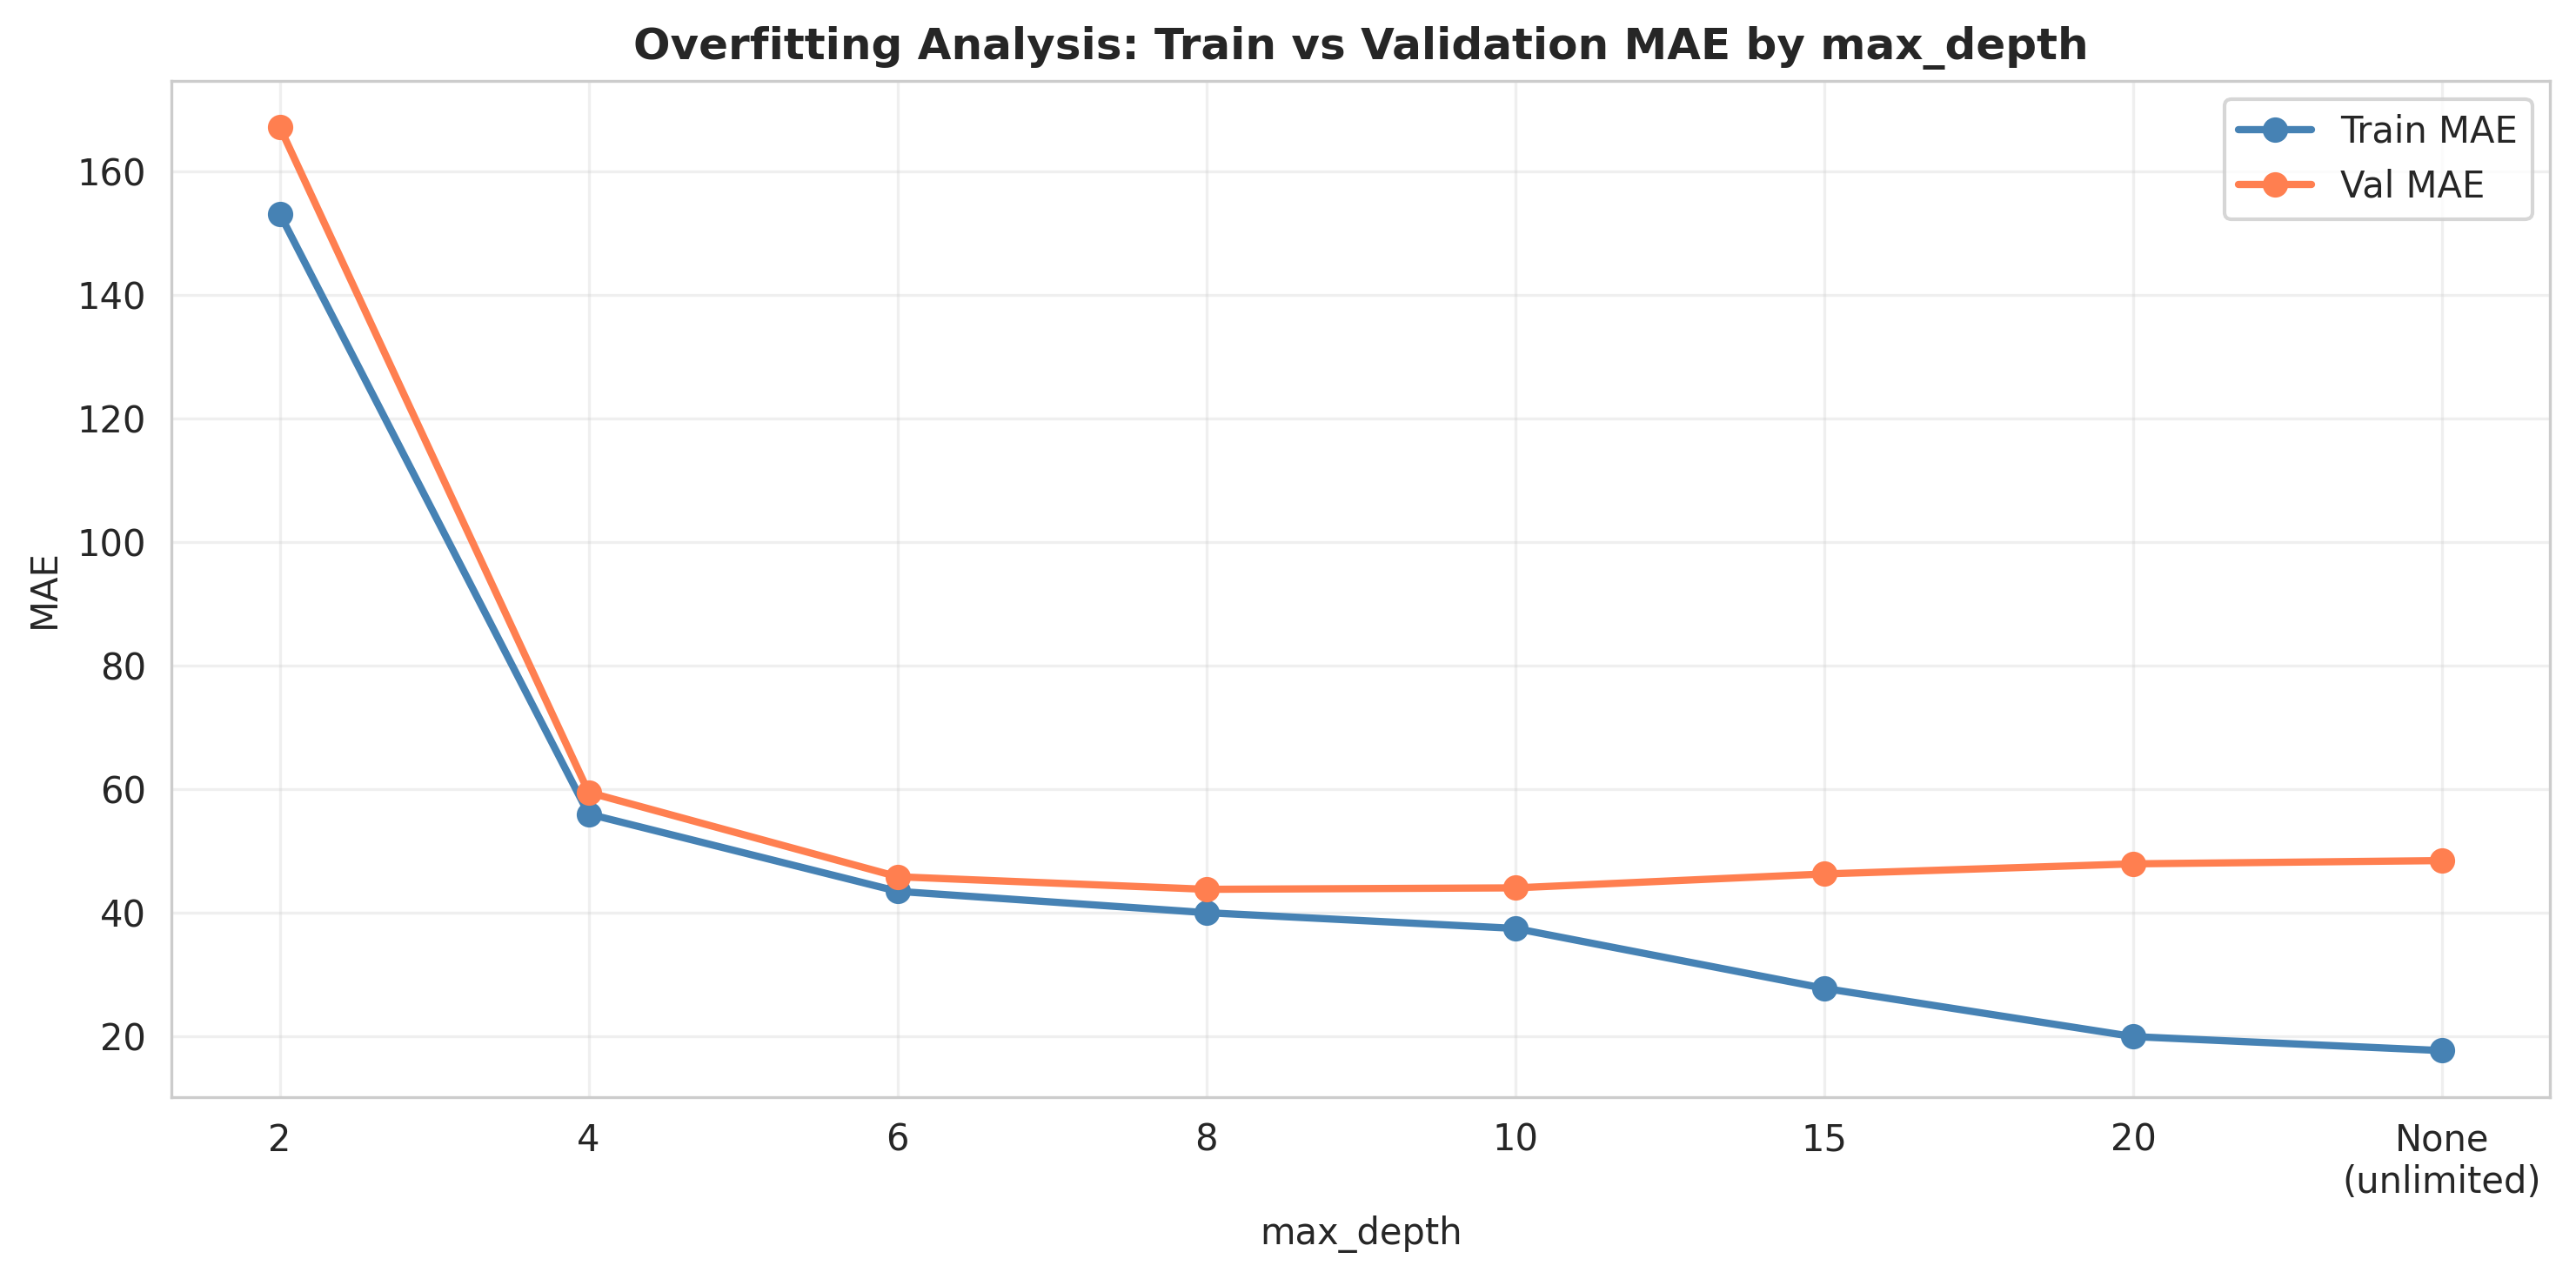


max_depth | Train MAE | Val MAE  | Gap
---------------------------------------------
2         |    153.07 |   167.11 | +14.04
4         |     55.98 |    59.48 | +3.50
6         |     43.47 |    45.84 | +2.36
8         |     40.02 |    43.80 | +3.78
10        |     37.47 |    44.03 | +6.56
15        |     27.78 |    46.28 | +18.50
20        |     19.98 |    47.92 | +27.94
None
(unlimited)|     17.71 |    48.45 | +30.74


In [39]:
# Overfitting analysis: track Train vs Val MAE across max_depth values
depths = [2, 4, 6, 8, 10, 15, 20, None]
train_maes = []
val_maes   = []

for depth in depths:
    m = RandomForestRegressor(
        n_estimators=200,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    m.fit(X_train, y_train)
    train_maes.append(mean_absolute_error(y_train, m.predict(X_train)))
    val_maes.append(mean_absolute_error(y_val,   m.predict(X_val)))

depth_labels = [str(d) if d is not None else 'None\n(unlimited)' for d in depths]

plt.figure(figsize=(10, 5))
plt.plot(depth_labels, train_maes, marker='o', label='Train MAE', color='steelblue', linewidth=2)
plt.plot(depth_labels, val_maes,   marker='o', label='Val MAE',   color='coral',     linewidth=2)
plt.xlabel('max_depth')
plt.ylabel('MAE')
plt.title('Overfitting Analysis: Train vs Validation MAE by max_depth', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nmax_depth | Train MAE | Val MAE  | Gap")
print("-" * 45)
for d, tr, va in zip(depth_labels, train_maes, val_maes):
    print(f"{str(d):<10}| {tr:>9.2f} | {va:>8.2f} | {va - tr:>+.2f}")

In [40]:
# Stage 1: Zero vs Non-Zero Classifier
y_train_binary = (y_train > 0).astype(int)

clf = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
)
clf.fit(X_train, y_train_binary)

p_nonzero_val = clf.predict_proba(X_val)[:, 1]

# Stage 2: Regressor on Non-Zero Rows Only
nonzero_mask = y_train > 0
reg_nz = RandomForestRegressor(
    n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
)
reg_nz.fit(X_train[nonzero_mask], y_train[nonzero_mask])

hurdle_pred_val = p_nonzero_val * reg_nz.predict(X_val)

hurdle_mae  = mean_absolute_error(y_val, hurdle_pred_val)
hurdle_rmse = np.sqrt(mean_squared_error(y_val, hurdle_pred_val))
hurdle_mape = np.mean(np.abs((y_val - hurdle_pred_val) / (y_val + 1))) * 100

print("Hurdle Model Results (Validation)")
print(f"  MAE:  {hurdle_mae:.2f}")
print(f"  RMSE: {hurdle_rmse:.2f}")
print(f"  MAPE: {hurdle_mape:.2f}%")

print("\nFull Model Comparison (Validation Set)")
print(f"{'Metric':<10} {'XGBoost':>10} {'Random Forest':>15} {'Hurdle RF':>12}")
print(f"{'MAE':<10} {xgb_val_mae:>10.2f} {rf_val_mae:>15.2f} {hurdle_mae:>12.2f}")
print(f"{'RMSE':<10} {xgb_val_rmse:>10.2f} {rf_val_rmse:>15.2f} {hurdle_rmse:>12.2f}")
print(f"{'MAPE':<10} {xgb_val_mape:>10.2f} {rf_val_mape:>15.2f} {hurdle_mape:>12.2f}")

Hurdle Model Results (Validation)
  MAE:  44.03
  RMSE: 126.14
  MAPE: 17.01%

Full Model Comparison (Validation Set)
Metric        XGBoost   Random Forest    Hurdle RF
MAE             47.92           44.03        44.03
RMSE           171.36          126.60       126.14
MAPE            18.14           17.01        17.01


In [41]:
# Tune on val set (time-safe, no random CV)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [6, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}

best_val_mae = float('inf')
best_params  = None

for params in ParameterGrid(param_grid):
    m = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    mae = mean_absolute_error(y_val, m.predict(X_val))
    if mae < best_val_mae:
        best_val_mae = mae
        best_params  = params

print(f"Best Val MAE: {best_val_mae:.2f}")
print(f"Best Params:  {best_params}")

# Retrain on train + val combined, then evaluate on test ONCE
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train_full, y_train_full)
best_pred = best_rf.predict(X_test)

best_mae  = mean_absolute_error(y_test, best_pred)
best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_mape = np.mean(np.abs((y_test - best_pred) / (y_test + 1))) * 100

# Train MAE on full train for final overfitting check
final_train_mae = mean_absolute_error(y_train_full, best_rf.predict(X_train_full))

print(f"\nFinal Model - Test Set Results")
print(f"  Train MAE: {final_train_mae:.2f}")
print(f"  Test  MAE: {best_mae:.2f}  (gap: {best_mae - final_train_mae:.2f})")
print(f"  Test RMSE: {best_rmse:.2f}")
print(f"  Test MAPE: {best_mape:.2f}%")

Best Val MAE: 43.89
Best Params:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}

Final Model - Test Set Results
  Train MAE: 38.10
  Test  MAE: 38.41  (gap: 0.31)
  Test RMSE: 109.68
  Test MAPE: 16.27%


In [42]:
# Re-run hotspot with tuned model
tuned_pred = best_rf.predict(X_test)

test_tuned = test.copy()
test_tuned['predicted'] = tuned_pred

hotspots_tuned = test_tuned.groupby('CSP Name merged', observed=True).agg(
    Actual_Total    = ('Offence Count', 'sum'),
    Predicted_Total = ('predicted', 'sum')
).sort_values('Predicted_Total', ascending=False).reset_index()

hotspots_tuned['Rank'] = range(1, len(hotspots_tuned) + 1)

print("TOP 15 HIGH-RISK CSPs - Tuned Model (2023/24 & 2024/25)")
print(hotspots_tuned[['Rank','CSP Name merged','Predicted_Total','Actual_Total']].head(15).to_string(index=False))

TOP 15 HIGH-RISK CSPs - Tuned Model (2023/24 & 2024/25)
 Rank CSP Name merged  Predicted_Total  Actual_Total
    1      Birmingham    283530.494167      275845.0
    2           Leeds    213941.485855      207132.0
    3      Manchester    193232.259166      181312.0
    4     Westminster    181758.828225      183686.0
    5        Bradford    146372.021742      139364.0
    6       Liverpool    127806.051038      127088.0
    7       Sheffield    122250.787169      119171.0
    8 City of Bristol    119926.068534      121324.0
    9   County Durham    104771.946115      100709.0
   10       Leicester     92832.374328       90808.0
   11        Kirklees     89091.982132       85037.0
   12       Wakefield     89037.767236       85526.0
   13        Somerset     87741.319463       89410.0
   14          Camden     83729.708185       83446.0
   15       Doncaster     81693.089085       79634.0


---
## Model Evaluation and Results

Visualizing prediction accuracy, residuals, and hotspot comparisons for the final tuned model.

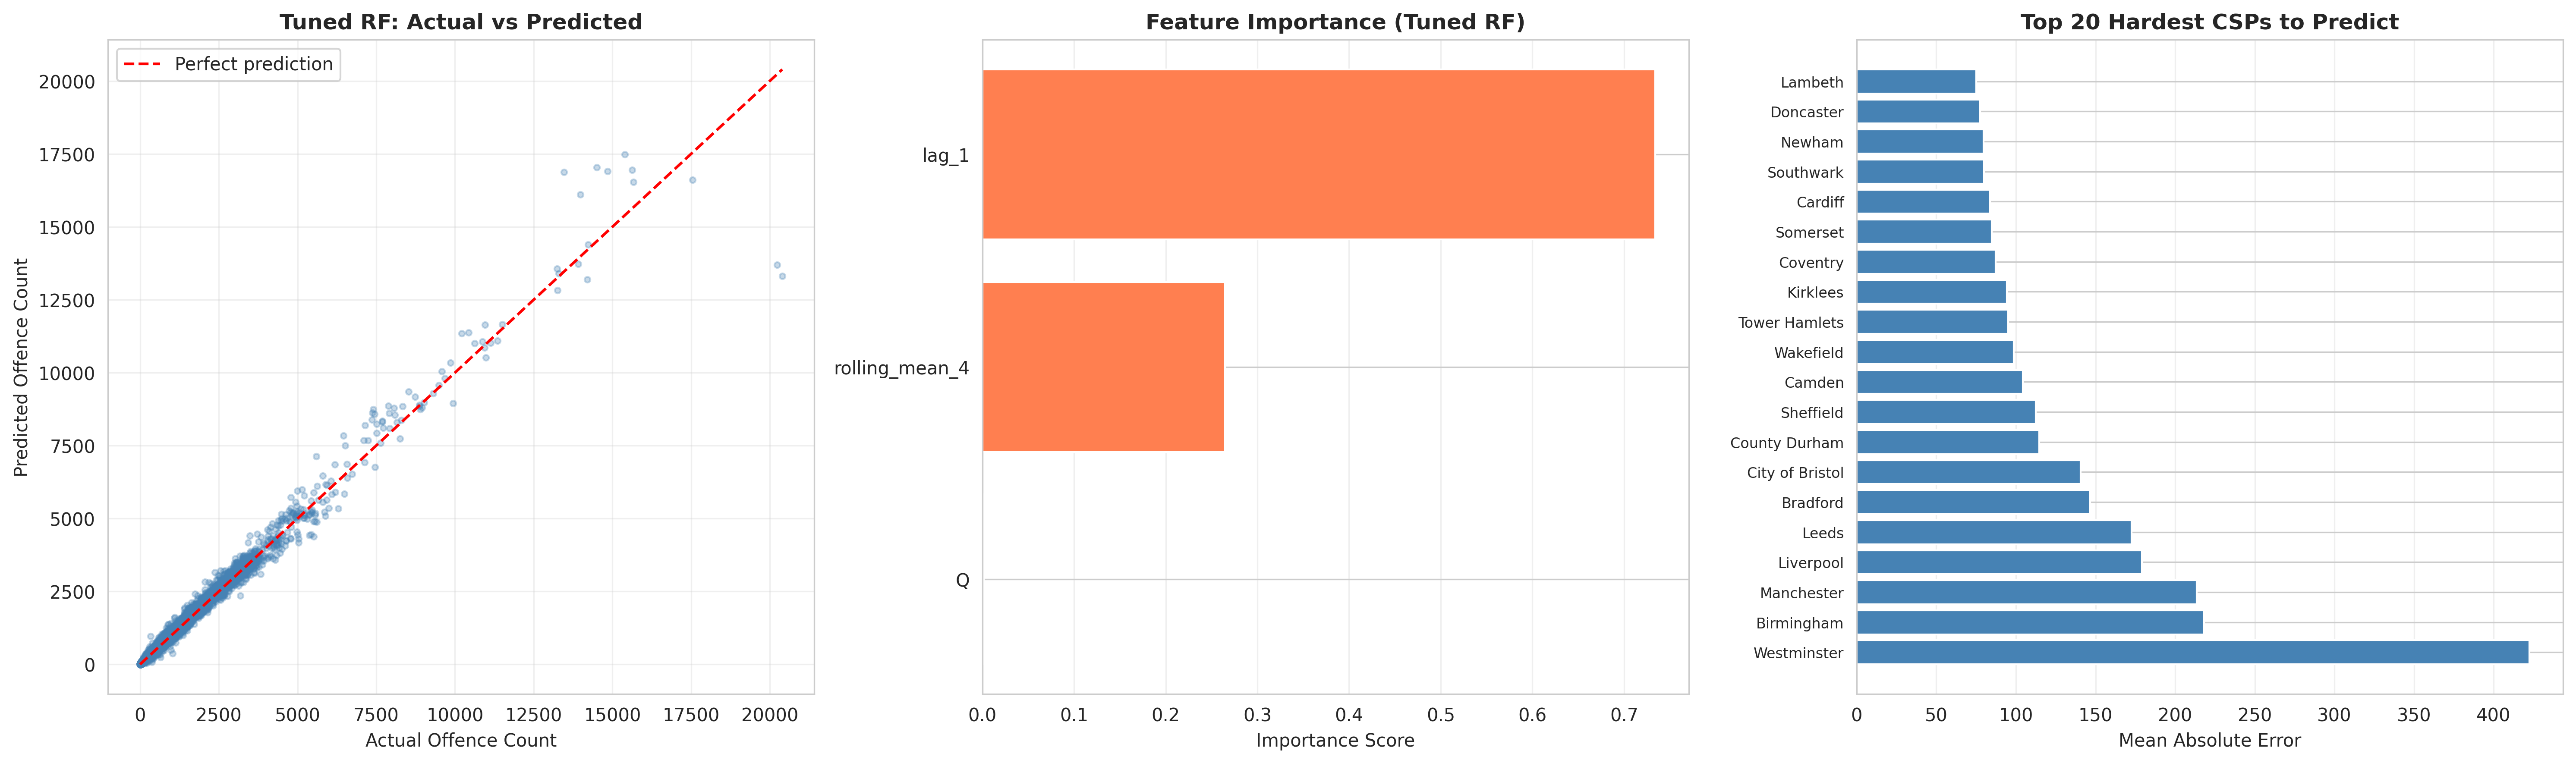

Overall Test MAE:  38.41
Overall Test RMSE: 109.68

Hardest CSPs to predict (highest MAE):
CSP Name merged
Westminster    422.474604
Birmingham     218.102316
Manchester     213.431007
Liverpool      179.008534
Leeds          172.585958

Easiest CSPs to predict (lowest MAE):
CSP Name merged
Isles of Scilly        1.706506
Rutland                7.407110
Manchester Airport     7.957215
Ribble Valley          8.756180
Three Rivers          10.539859


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Actual vs Predicted scatter
axes[0].scatter(y_test, best_pred, alpha=0.3, s=10, color='steelblue')
max_val = max(y_test.max(), best_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Offence Count')
axes[0].set_ylabel('Predicted Offence Count')
axes[0].set_title('Tuned RF: Actual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Feature importance
feat_importance = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=True)
axes[1].barh(feat_importance.index, feat_importance.values, color='coral')
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Feature Importance (Tuned RF)', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Plot 3: Prediction accuracy by CSP (MAE per CSP, top 20 hardest to predict)
test_eval = test.copy()
test_eval['predicted'] = best_pred
test_eval['abs_error'] = (test_eval['Offence Count'] - test_eval['predicted']).abs()

csp_mae = test_eval.groupby('CSP Name merged', observed=True)['abs_error'].mean()
top20_hardest = csp_mae.sort_values(ascending=False).head(20)

axes[2].barh(range(len(top20_hardest)), top20_hardest.values, color='steelblue')
axes[2].set_yticks(range(len(top20_hardest)))
axes[2].set_yticklabels(top20_hardest.index, fontsize=8)
axes[2].set_xlabel('Mean Absolute Error')
axes[2].set_title('Top 20 Hardest CSPs to Predict', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Overall Test MAE:  {best_mae:.2f}")
print(f"Overall Test RMSE: {best_rmse:.2f}")
print(f"\nHardest CSPs to predict (highest MAE):")
print(top20_hardest.head(5).to_string())
print(f"\nEasiest CSPs to predict (lowest MAE):")
print(csp_mae.sort_values().head(5).to_string())

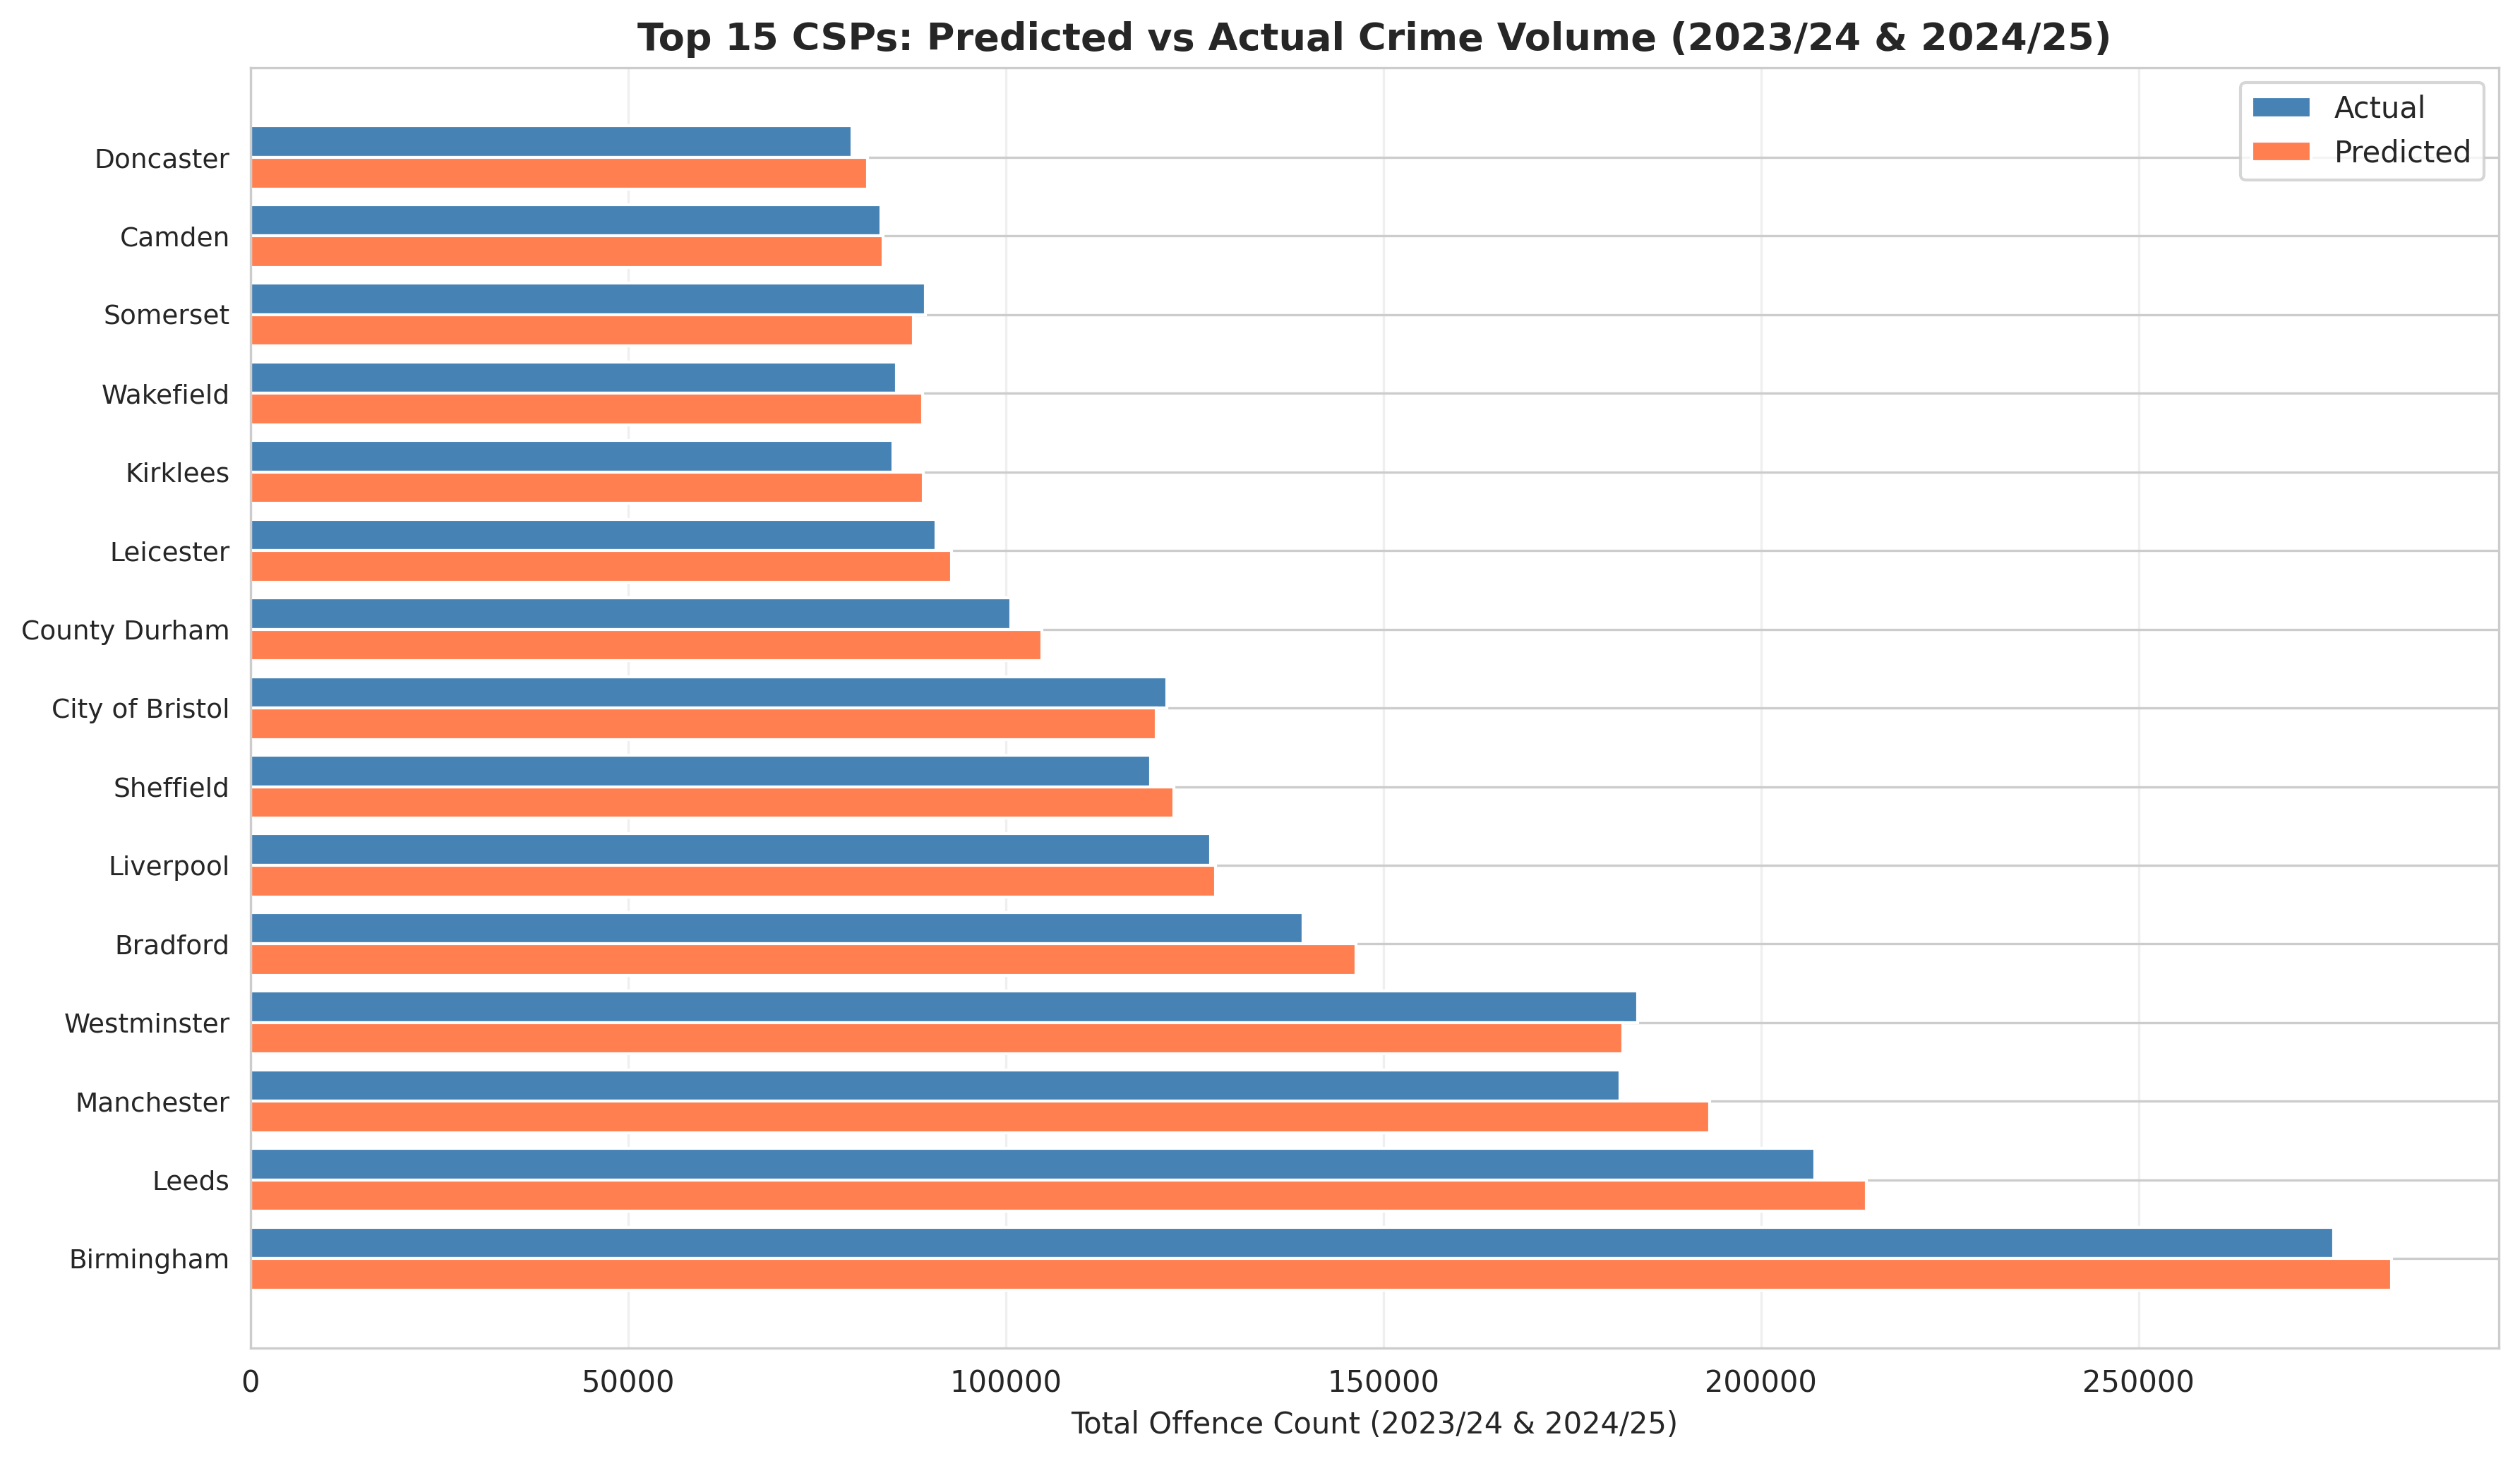

In [46]:
# bar chart comparing predicted vs actual for top 15 hotspots
fig, ax = plt.subplots(figsize=(12, 7))
top15 = hotspots_tuned.head(15)
x = range(len(top15))
width = 0.4

ax.barh([i + width/2 for i in x], top15['Actual_Total'],    width, label='Actual',    color='steelblue')
ax.barh([i - width/2 for i in x], top15['Predicted_Total'], width, label='Predicted', color='coral')
ax.set_yticks(x)
ax.set_yticklabels(top15['CSP Name merged'], fontsize=9)
ax.set_xlabel('Total Offence Count (2023/24 & 2024/25)')
ax.set_title('Top 15 CSPs: Predicted vs Actual Crime Volume (2023/24 & 2024/25)', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('hotspot_ranking.png', dpi=300, bbox_inches='tight')
plt.show()